In [ ]:
import numpy as np

A = np.arange(1, 26).reshape(5, 5)
A

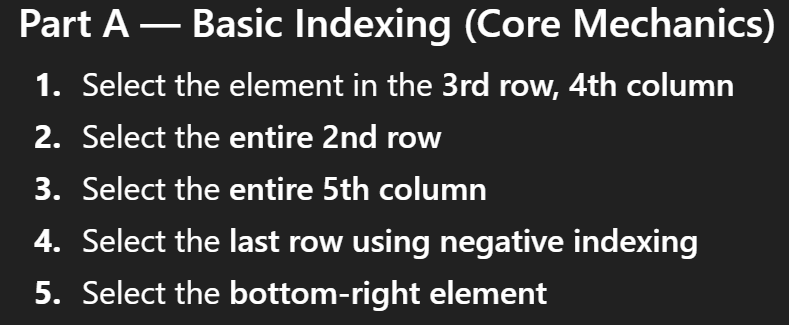

In [ ]:
# 1. Select the element in the 3rd row, 4th column.
print(A[2, 3], "\n")

# 2. Select the entire 2nd row.
print(A[1], "\n")

# 3. Select the entire 5th row.
print(A[:, 4], "\n")

# 4. Select the last row using negative indexing
print(A[-1], "\n")

# 5. Select the bottom-right element
print(A[-1, -1], "\n")

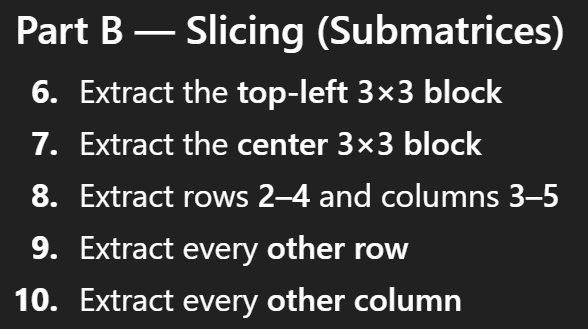

In [ ]:
# 6. Extract the top-left 3×3 block
print(A[:3, :3], "\n")

# 7. Extract the center 3×3 block
print(A[1:4, 1:4], "\n")

# 8. Extract rows 2–4 and columns 3–5
print(A[1:4, 2:5], "\n")

# 9. Extract every other row
print(A[::2, :], "\n")

# 10. Extract every other column
print(A[:, ::-1], "\n")

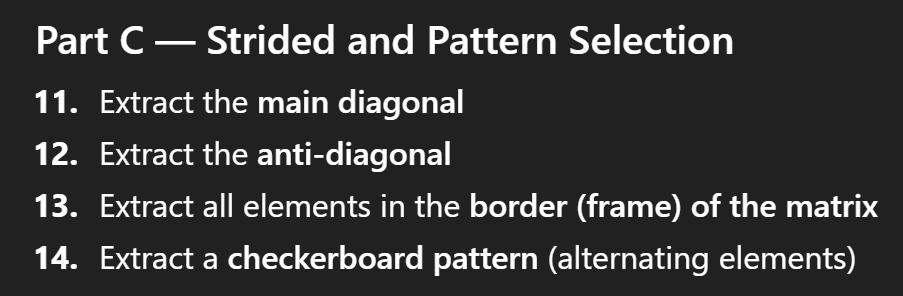

In [ ]:
# 11. Extract the main diagonal
print(np.diag(A), "\n")

# 12. Extract the anti-diagonal
print(np.diag(np.fliplr(A)), "\n")

# 13. Extract all elements in the border (frame) of the matrix
top = A[0, :]
left = A[:, 0]
bottom = A[-1, :]
right = A[:, -1]

print(np.concatenate((top, left, bottom, right)), "\n")

# 14.

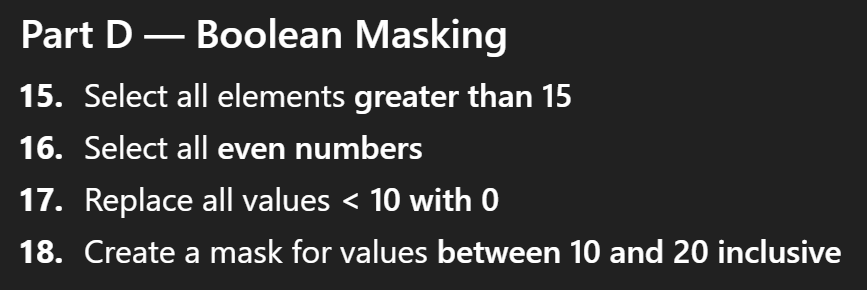

In [ ]:
# 15. Select all elements greater than 15
mask = A > 15
print(A[mask], "\n")

# 16. Select all even numbers
mask = (A % 2 == 0)
print(A[mask], "\n")

# 17. Replace all values < 10 with 0
print(np.where(A < 10, 0, A), "\n")

# 18. Create a mask for values between 10 and 20 inclusive
mask = (A >= 10) & (A <= 20)
print(A[mask], "\n")

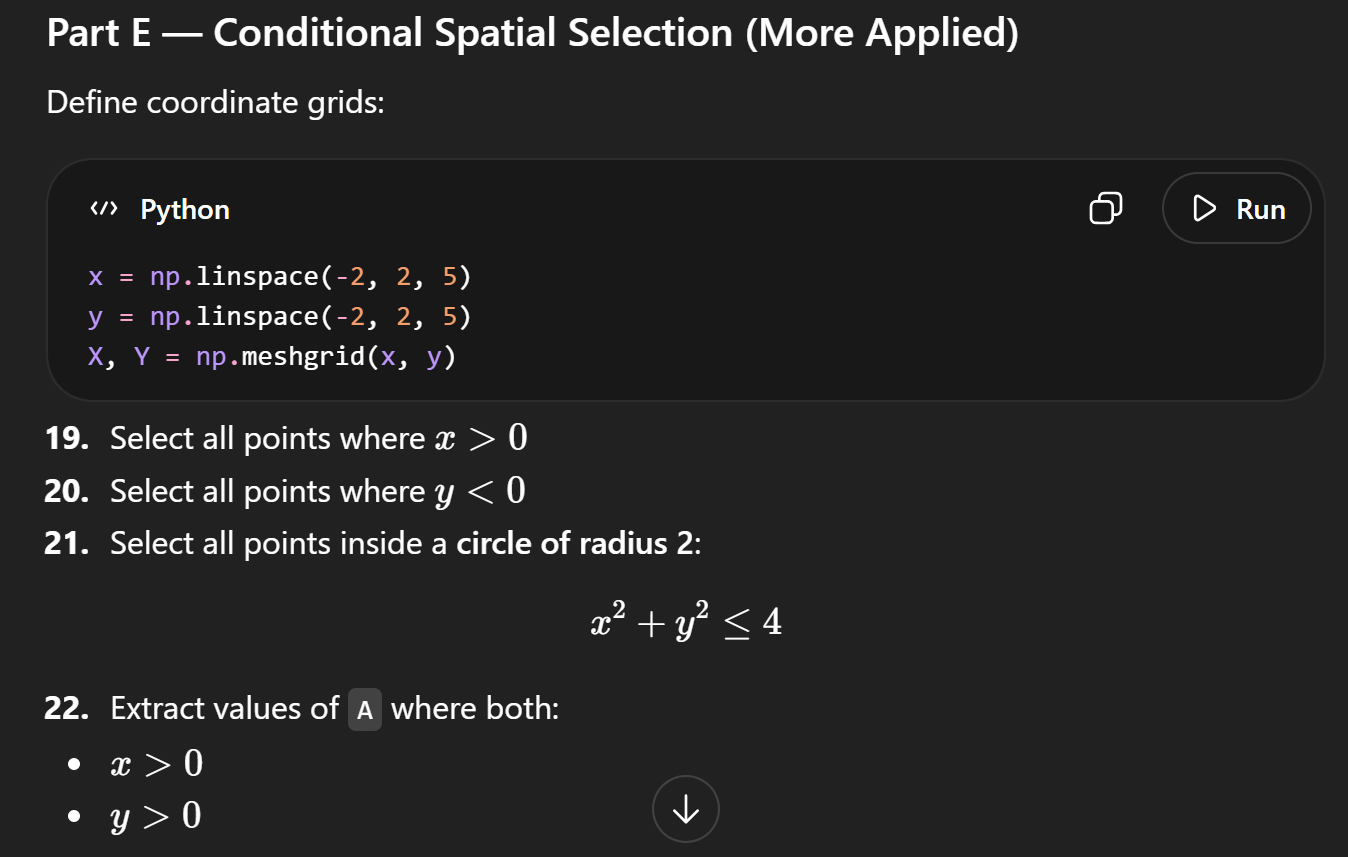

In [ ]:
x = np.linspace(-2, 2, 5)
y = np.linspace(-2, 2, 5)
X, Y = np.meshgrid(x, y)

# 19. Select all points where x>0
print(A[X > 0], "\n")

# 20. Select all points where y<0
print(A[Y < 0], "\n")

# 21. inside circle: x^2 + y^2 ≤ 4
mask_circle = X**2 + Y**2 <= 4
A[mask_circle]

In [ ]:
X

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from src import total_derivatives

x = np.linspace(0, 2*np.pi, 11)
y = np.linspace(0, 2*np.pi, 11)
X, Y = np.meshgrid(x, y)

f = np.sin(X + Y)

fig, ax = plt.subplots()
c = ax.contourf(X, Y, f)
fig.colorbar(c)
plt.show()

In [ ]:
j = np.argmin(np.abs(y - 3))
row = f[j, :]

row

In [ ]:
total_derivatives.biased_central_difference_approximation(f[j, :], x)

In [ ]:
dfdx = np.zeros_like(f)

for i in range(f.shape[0]):   # loop over rows (y-direction)
    dfdx[i, :] = total_derivatives.biased_central_difference_approximation(
        f[i, :], x
    )

In [ ]:
dfdx

In [ ]:
fig, ax = plt.subplots()
c = ax.contourf(X, Y, dfdx)
fig.colorbar(c)
ax.set_title("∂f/∂x")
plt.show()

In [ ]:
dfdx = np.apply_along_axis(
    total_derivatives.biased_central_difference_approximation,
    axis=1,
    arr=f,
    domain=x
)

In [ ]:
fig, ax = plt.subplots()
c = ax.contourf(X, Y, dfdx)
fig.colorbar(c)
ax.set_title("∂f/∂x")
plt.show()

In [ ]:
dfdx

In [ ]:
import numpy as np

import src.total_derivatives


class Partial:
    def __init__(
            self,
            function: np.ndarray,
            x: np.ndarray = None,
            y: np.ndarray = None
    ) -> None:
        self.function = function
        self.x = x if x is not None else np.linspace(0, 1, function.shape[1])
        self.y = y if y is not None else np.linspace(0, 1, function.shape[0])

    def biased_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def biased_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def periodic_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def biased_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

In [ ]:
Partial(f, x, y).dx()

In [ ]:
f.shape[0]

In [ ]:
import numpy as np

import src.total_derivatives


class Partial:
    def __init__(
            self,
            function: np.ndarray,
            x: np.ndarray = None,
            y: np.ndarray = None
    ) -> None:
        self.function = function
        self.x = x if x is not None else np.linspace(0, 1, function.shape[1])
        self.y = y if y is not None else np.linspace(0, 1, function.shape[0])

    def biased_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def biased_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def periodic_dy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def biased_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def periodic_dxx(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )

    def biased_dyy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )

    def periodic_dyy(self) -> np.ndarray:
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


x = np.linspace(0, 1, 101)
y = np.linspace(0, 1, 101)
X, Y = np.meshgrid(x, y)

psi = X * (1 - X) * Y * (1 - Y)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
c = ax.pcolormesh(X, Y, psi)
fig.colorbar(c)
plt.show()

In [ ]:
u = Partial(psi, x, y).biased_dy()

fig, ax = plt.subplots(figsize=(6, 6))
c = ax.pcolormesh(X, Y, u)
fig.colorbar(c)
plt.show()



In [ ]:
import numpy as np

import src.total_derivatives


class Partial:
    def __init__(
            self,
            function: np.ndarray,
            x: np.ndarray = None,
            y: np.ndarray = None
    ) -> \
            None:
        self.function = function
        self.x = x if x is not None else np.linspace(0, 1, function.shape[1])
        self.y = y if y is not None else np.linspace(0, 1, function.shape[0])


    def x_is_periodic(self) -> bool:
        """
        Check if function is periodic in x-direction.
        Compares first and last columns.
        """
        return np.allclose(self.function[:, 0], self.function[:, -1])


    def y_is_periodic(self) -> bool:
        """
        Check if function is periodic in y-direction.
        Compares first and last rows.
        """
        return np.allclose(self.function[0, :], self.function[-1, :])


    def biased_dx(self) -> np.ndarray:
        """
        Uses central difference approximation for interior points, forward difference approximation
        at the first point, and backwards difference approximation at the last point to compute the
        partial derivative with respect to x-direction in uniform grids.
        """
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def periodic_dx(self) -> np.ndarray:
        """Uses periodic wrapping at boundaries along with central difference approximation
         to compute the partial derivative with respect to x-direction."""
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def biased_dy(self) -> np.ndarray:
        """
        Uses central difference approximation for interior points, forward difference approximation
        at the first point, and backwards difference approximation at the last point to compute the
        partial derivative with respect to y-direction in uniform grids.
        """
        return np.apply_along_axis(
            src.total_derivatives.biased_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def periodic_dy(self) -> np.ndarray:
        """Uses periodic wrapping at boundaries along with central difference approximation
         to compute the partial derivative with respect to y-direction in uniform grids."""
        return np.apply_along_axis(
            src.total_derivatives.periodic_central_difference_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def dx(self) -> np.ndarray:
        """
        Compute the partial derivative with respect to x-direction in uniform grids choosing
        the most appropriate scheme to handle the boundary conditions (biased or periodic).
        """
        if self.x_is_periodic():
            return self.periodic_dx()
        else:
            return self.biased_dx()


    def dy(self) -> np.ndarray:
        """
        Compute the partial derivative with respect to y-direction in uniform grids choosing
        the most appropriate scheme to handle the boundary conditions (biased or periodic).
        """
        if self.y_is_periodic():
            return self.periodic_dy()
        else:
            return self.biased_dy()


    def biased_dxx(self) -> np.ndarray:
        """
        Compute the second order partial derivative approximation with respect to x in
        uniform grids using biased forward difference approximation for the
        first step and biased backward difference approximation for the last step.
        """
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def periodic_dxx(self) -> np.ndarray:
        """
        Compute the second order partial derivative approximation in uniform grids
        with respect to the x-direction of the function in uniform grids using the
        periodic boundary condition.
        """
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=1,
            arr=self.function,
            domain=self.x
        )


    def biased_dyy(self) -> np.ndarray:
        """
        Compute the second order partial derivative approximation with respect to y in
        uniform grids using biased forward difference approximation for the
        first step and biased backward difference approximation for the last step.
        """
        return np.apply_along_axis(
            src.total_derivatives.biased_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def periodic_dyy(self) -> np.ndarray:
        """
        Compute the second order partial derivative approximation with respect to the y-direction
        of the function in uniform grids using the periodic boundary condition.
        """
        return np.apply_along_axis(
            src.total_derivatives.periodic_second_order_derivative_approximation,
            axis=0,
            arr=self.function,
            domain=self.y
        )


    def dxx(self):
        """Compute the second order partial derivative with respect to x-direction
        with the most appropriate scheme."""
        if self.x_is_periodic():
            return self.periodic_dxx()
        else:
            return self.biased_dxx()


    def dyy(self):
        """Compute the second order partial derivative with respect to y-direction
        with the most appropriate scheme."""
        if self.y_is_periodic():
            return self.periodic_dyy()
        else:
            return self.biased_dyy()


    def at_x0(self, x0: float) -> np.ndarray:
        x0 = np.argmin(self.x - x0)
        return None


    def __str__(self) -> str:
        return (
            f"Partial(field shape = {self.function.shape},"
            f"x = {self.x},"
            f"y = {self.y}),"
            f"x_periodic={self.x_is_periodic()}, "
            f"y_periodic={self.y_is_periodic()})"
        )


    def __repr__(self) -> str:
        return (
            f"Partial(function=np.array(shape={self.function.shape}), "
            f"x=np.array(len={len(self.x)}), "
            f"y=np.array(len={len(self.y)}))"
        )


    def __add__(self, other):
        if not isinstance(other, Partial):
            return NotImplemented

        if self.function.shape != other.function.shape:
            raise ValueError("Function shapes must match.")

        if not np.allclose(self.x, other.x) or not np.allclose(self.y, other.y):
            raise ValueError("Domains must match.")

        return Partial(
            self.function + other.function,
            self.x,
            other.y
        )

    def __sub__(self, other):
        if not isinstance(other, Partial):
            return NotImplemented

        if self.function.shape != other.function.shape:
            raise ValueError("Function shapes must match.")

        if not np.allclose(self.x, other.x) or not np.allclose(self.y, other.y):
            raise ValueError("Domains must match.")

        return Partial(
            self.function - other.function,
            self.x,
            other.y
        )

    def __mul__(self, other: float):
        return Partial(self.function * other, self.x, self.y)

# Setup Grid
x = np.linspace(0, 1, 101)
y = np.linspace(0, 1, 101)
X, Y = np.meshgrid(x, y)

# Define stream function
psi = X * (1 - X) * Y * (1 - Y)

# Define wind components
u = Partial(psi, x, y).biased_dy()
v = - Partial(psi, x, y).biased_dx()

# Define vorticity
vorticity = - Partial(psi, x, y).biased_dxx() - Partial(psi, x, y).biased_dyy()
# vorticity = Partial(v, x, y).biased_dx() - Partial(u, x, y).biased_dy()

# Define enstrophy
enstrophy_density = 0.5 * vorticity**2

# Define divergence
divergence = Partial(u, x, y).biased_dx() + Partial(v, x, y).biased_dy()

# Define strain
strain = 0.5 * (Partial(psi, x, y).biased_dyy() - Partial(psi, x, y).biased_dxx())


print(psi)

In [ ]:
psi.shape

In [ ]:
import matplotlib.pyplot as plt

step = 5

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# Stream Function and wind
c1 = ax1.pcolormesh(X, Y, psi)
ax1.set_title("Stream function and wind")
ax1.streamplot(X[::step, ::step], Y[::step, ::step], u[::step, ::step], v[::step, ::step])
fig.colorbar(c1)

# Enstrophy
c2 = ax2.pcolormesh(X, Y, enstrophy_density)
ax2.set_title("Enstrophy density")
fig.colorbar(c2)

# Divergence
c3 = ax3.pcolormesh(X, Y, divergence)
ax3.set_title("Divergence")
fig.colorbar(c3)

# Strain
c4 = ax4.pcolormesh(X, Y, strain)
ax4.set_title("Strain")
fig.colorbar(c4)

plt.show()

In [ ]:
u

In [ ]:
import numpy as np

def build_matrix(n):
    A = np.zeros((n, n))

    # interior 1/2 bands
    # A += np.diag(0.5 * np.ones(n-1), k=1)
    # A += np.diag(0.5 * np.ones(n-1), k=-1)

    # # first row
    # A[0, 0] = h
    #
    # # second row: [0, 1, 1, 0, ...]
    # A[1, 1] = 1
    # A[1, 2] = 1
    #
    # # last row: [..., 1, 1]
    # A[-1, -2] = 1
    # A[-1, -1] = 1

    return A

A = build_matrix(5)
A


In [ ]:
A = np.zeros((5, 5))
A += np.diag

In [ ]:
A = np.ones((2, 2))
B = np.zeros((2, 2))

H = np.hstack((A, B))
V = np.vstack((A, B))

V

In [ ]:
M = np.block([
    [A, B],
    [B, A]
])

M

In [ ]:
A = np.zeros((4, 4))

A[0, :] = 1        # first row
A[:, 0] = 2        # first column
A[1:3, 1:3] = 5    # submatrix

A

In [ ]:
n = 4

main = 2 * np.ones(n)
upper = -1 * np.ones(n-1)
lower = -1 * np.ones(n-1)

A = np.diag(main) + np.diag(upper, 1) + np.diag(lower, -1)

In [ ]:
np.diag(main)

In [ ]:
np.diag(upper, 1)

In [ ]:
A = (
    np.diag(np.ones(5)) +
    np.diag(2*np.ones(4), 1) +
    np.diag(3*np.ones(4), -1)
)
A

In [ ]:
A = np.zeros((10, 10))
A += np.diag(0.5 * np.ones(10-1), k=1)
A += np.diag(0.5 * np.ones(10-1), k=-1)
A[0, 0:2] = np.array([-1, 1])
A[-1, -2:] = np.array([-1, 1])
A

In [ ]:
def transformation_matrix(n: int) -> np.ndarray:
    """Defines the n x n transformation matrix necessary to solve the problem."""
    H = np.zeros((n, n))
    H += np.diag(0.5 * np.ones(n - 1), k=1)
    H += np.diag(-0.5 * np.ones(n - 1), k=-1)
    H[0, :2] = np.array([-1, 1])
    H[-1, -2:] = np.array([-1, 1])
    return H

In [ ]:
A = transformation_matrix(10)
PI = np.ones_like(A)
A - PI

In [ ]:
np.linalg.inv(A - PI)

In [ ]:
# %%
import matplotlib.pyplot as plt
import numpy as np


g = 9.81
Rd = 287.1
gamma = 6.5e-3

n = 1_001
z = np.linspace(0, 100_000, n)
theta_profile  = 300.0 + gamma * z
exner_0 = 1
exner_0_vector = exner_0 * np.ones(n)
h = z[1] - z[0]


def exner(theta: float | np.ndarray) -> float | np.ndarray:
    exner_profile = - g / (Rd * theta)
    return exner_profile


def transformation_matrix(n: int) -> np.ndarray:
    """Defines the n x n transformation matrix necessary to solve the problem."""
    H = np.zeros((n, n))
    H += np.diag(0.5 * np.ones(n - 1), k=1)
    H += np.diag(-0.5 * np.ones(n - 1), k=-1)
    H[0, :2] = np.array([-1, 1])
    H[-1, -2:] = np.array([-1, 1])
    return H


H = transformation_matrix(n)
dpi_dz = exner(theta_profile)
hydrostatic_pressure = h * np.linalg.inv(H - exner_0_vector) @ dpi_dz

print(hydrostatic_pressure.shape)

# y = exner(theta_profile)
#
# fig, ax = plt.subplots()
# ax.plot(y, z)
# plt.show()

In [ ]:
dpi_dz.shape

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Grid ---
n = 101
x = np.linspace(0, 1, n)
dx = x[1] - x[0]

# --- Source term ---
def s_func(x):
    return 10 * np.sin(np.pi * x)

# --- Matrix builder ---
def diffusion_matrix(n: int, dx: float) -> np.ndarray:
    H = np.zeros((n, n))

    # Interior: second-order centered difference
    H += np.diag(-1 * np.ones(n - 1), k=1)
    H += np.diag(2 * np.ones(n))
    H += np.diag(-1 * np.ones(n - 1), k=-1)

    # Scale interior rows
    H[1:-1, :] /= dx**2

    # Bottom boundary (Neumann): du/dx = alpha
    H[0, :3] = np.array([-1.5, 2.0, -0.5]) / dx

    # Top boundary (Dirichlet): u = beta
    H[-1, :] = 0
    H[-1, -1] = 1.0

    return H

# --- RHS vector ---
def rhs_vector(x, dx, alpha, beta):
    n = len(x)
    b = np.zeros(n)

    s = s_func(x)

    # Bottom boundary
    b[0] = alpha

    # Interior (note: NO dx^2 scaling since it's already in matrix)
    b[1:-1] = s[1:-1]

    # Top boundary
    b[-1] = beta

    return b

# --- Parameters ---
alpha = 0.0   # bottom flux
beta = 0.0    # top value

# --- Build system ---
H = diffusion_matrix(n, dx)
b = rhs_vector(x, dx, alpha, beta)

# --- Solve ---
u = np.linalg.solve(H, b)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.plot(x, s_func(x))
ax1.set_title("Source term s(x)")

ax2.plot(x, u)
ax2.set_title("Solution u(x)")

plt.tight_layout()
plt.show()

In [ ]:
# %%
import matplotlib.pyplot as plt
import numpy as np


n = 1001
x = np.linspace(0, 1, n)
dx = x[1] - x[0]
s1 = 10 * np.sin(np.pi * x)
s2 = (0.5 * np.pi)**2 * np.cos(0.5 * np.pi * x)
u_analytic = - np.cos(0.5 * np.pi * x)
bcs = np.zeros_like(x)
bcs_0 = s


def diffusion_matrix(n: int) -> np.ndarray:
    """Defines the n x n transformation matrix necessary to solve the diffusion problem."""
    H = np.zeros((n, n))
    H += np.diag(-1 * np.ones(n - 1), k=1)
    H += np.diag(2 * np.ones(n))
    H += np.diag(-1 * np.ones(n - 1), k=-1)
    H[0, :3] = np.array([-1.5, 2.0, -0.5])
    H[-1, :] = 0
    H[-1, -1] = 1.0
    return H


def bcs(lower: float, upper: float, function: np.ndarray) -> np.ndarray:
    """
    Boundary conditions vector given the values of the lower boundary, upper boundary and the
    function.
    """
    bcs_vector = np.zeros_like(function)
    bcs_vector[0] = lower
    bcs_vector[-1] = upper
    return bcs_vector

H = diffusion_matrix(n)

u = np.linalg.inv(H) @ (s1 * -dx**2 + bcs(0, 0, s1))
# y = 10 / ((np.pi)**2) * np.sin(np.pi * x)
y = x**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.set_title("Source term s(x)")
ax1.plot(x, s1)
ax2.set_title("Solution u(x)")
ax2.plot(x, u)
ax2.plot(x, u_analytic, marker="o")

plt.show()

In [ ]:
n = 200
x = np.linspace(0, 1, n)
dx = x[1] - x[0]
s1 = 10 * np.sin(np.pi * x)
s2 = (0.5 * np.pi)**2 * np.cos(0.5 * np.pi * x)
u_analytic = - np.cos(0.5 * np.pi * x)
bcs = np.zeros_like(u_analytic)

lower = 0.5 * (-3*s1[2] + 4*s1[1] - s1[0]) / dx

bcs[0] = lower

bcs

In [ ]:
import sympy as smp
x = smp.Symbol('x')

s1 = -10 * smp.sin(smp.pi * x)

I1 = smp.integrate(s1, x)
I2 = smp.integrate(I1, x)
I2

In [ ]:
I2.diff().doit()

In [ ]:
import numpy as np

n = 5
H = np.zeros((n, n))
H

In [ ]:
np.diag(-1 * np.ones(n - 1), k=-1)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def bcs(lower, upper, function):
    bc = np.zeros_like(function)
    bc[0] = lower
    bc[-1] = upper
    return bc


def diffusion_matrix(n):
    H = np.zeros((n, n))

    # Interior stencil
    H += np.diag(-np.ones(n - 1), 1)
    H += np.diag(2 * np.ones(n), 0)
    H += np.diag(-np.ones(n - 1), -1)

    # Neumann BC at bottom
    H[0, :] = 0
    H[0, :3] = [1.5, -2.0, 0.5]

    # Dirichlet BC at top
    H[-1, :] = 0
    H[-1, -1] = 1

    return H


n = 101
x = np.linspace(0, 1, n)
dx = x[1] - x[0]

s1 = 10 * np.sin(np.pi * x)

# Correct analytic solution
u_analytic = -(10 / np.pi**2) * np.sin(np.pi * x)

H = diffusion_matrix(n)

alpha = 10 / np.pi
beta = 0

lower = dx * alpha
upper = beta

bc = bcs(lower, upper, s1)

rhs = -dx**2 * s1 + bc

u = np.linalg.solve(H, rhs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.set_title("Source term")
ax1.plot(x, s1)

ax2.set_title("Solution")
ax2.plot(x, u, label="Numerical")
ax2.plot(x, u_analytic, "--", label="Analytic")

ax2.legend()

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
sigma = 10
r = 28
b = 8/3

# Time settings
dt = 0.01
tf = 60

t = np.arange(0, tf + dt, dt)
nt = len(t)

# Allocate arrays
X = np.zeros(nt)
Y = np.zeros(nt)
Z = np.zeros(nt)

# Initial conditions
X[0] = 0
Y[0] = 1
Z[0] = 0


def lorenz(x, y, z):
    dxdt = -sigma * x + sigma * y
    dydt = -x * z + r * x - y
    dzdt = x * y - b * z

    return np.array([dxdt, dydt, dzdt])


# RK3 integration
for n in range(nt - 1):

        u_n = np.array([X[n], Y[n], Z[n]])

    k1 = lorenz(*u_n)

    k2 = lorenz(*(u_n + 0.5 * dt * k1))

    k3 = lorenz(*(u_n - dt * k1 + 2 * dt * k2))

    u_next = u_n + (dt / 6) * (k1 + 4 * k2 + k3)

    X[n+1], Y[n+1], Z[n+1] = u_next


# Plot time series
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t, X)
ax[0].set_ylabel('X')

ax[1].plot(t, Y)
ax[1].set_ylabel('Y')

ax[2].plot(t, Z)
ax[2].set_ylabel('Z')
ax[2].set_xlabel('Time')

plt.tight_layout()
plt.show()


# 3D attractor plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(X, Y, Z, lw=0.5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

In [ ]:
sigma = 10
r = 28
b = 8/3

def lorenz_rhs(u):

    X, Y, Z = u

    dXdt = -sigma * X + sigma * Y
    dYdt = -X * Z + r * X - Y
    dZdt = X * Y - b * Z

    return np.array([dXdt, dYdt, dZdt])

In [ ]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Create figure and axis
fig, ax = plt.subplots()

# Data
x = np.linspace(0, 2*np.pi, 500)
line, = ax.plot(x, np.sin(x))

# Axis limits
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(-1.2, 1.2)

# Animation update function
def update(frame):
    line.set_ydata(np.sin(x + frame / 10))
    return line,

# Create animation
ani = FuncAnimation(
    fig,
    update,
    frames=100,
    interval=50,
    blit=True
)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# constants
K = 1
uhat = 0.1
C = 1
h = 0.011

# wavenumber range
omega = np.linspace(0, np.pi, 2000)

# eigenvalue expression
real = 2 * uhat * (np.cos(omega) - 1) / h**2
imag = - uhat * np.sin(omega) / h

# plot
plt.figure(figsize=(7,6))
plt.plot(real*h, imag*h, lw=2)
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)

plt.xlabel("Re(λ)")
plt.ylabel("Im(λ)")
plt.title("Eigenvalues of FD Operator (K=C=uhat=1, h=0.01)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Stability boundary: lambda*dt = i*y, |y| <= 2
y = np.linspace(-2, 2, 400)
x = np.zeros_like(y)

plt.figure(figsize=(6,6))
plt.plot(x, y, 'b', lw=3, label='Leapfrog stability region')

# Add axes
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)

plt.xlabel("Re(λ Δt)")
plt.ylabel("Im(λ Δt)")
plt.title("Stability Region of the Leapfrog Method")
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Complex plane
xr = np.linspace(-6, 6, 500)
yi = np.linspace(-6, 6, 500)

X, Y = np.meshgrid(xr, yi)
Z = X + 1j * Y

# Crank-Nicolson amplification factor
G = (1 + Z/2) / (1 - Z/2)

# Magnitude
Gmag = np.abs(G)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Stable region: |G| <= 1
ax.contourf(X, Y, Gmag, levels=[0, 1], alpha=0.4)

# Stability boundary: |G| = 1
ax.contour(X, Y, Gmag, levels=[1], linewidths=2)

# Axes
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)

ax.set_xlabel(r'$\mathrm{Re}(z)$')
ax.set_ylabel(r'$\mathrm{Im}(z)$')
ax.set_title('Crank-Nicolson Stability Region')

ax.set_aspect('equal')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Complex plane
xr = np.linspace(-4, 2, 1000)
yi = np.linspace(-4, 4, 1000)

X, Y = np.meshgrid(xr, yi)
Z = X + 1j * Y

# RK3 stability function
R = 1 + Z + Z**2/2 + Z**3/6

# Magnitude
Rmag = np.abs(R)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Stable region: |R(z)| <= 1
ax.contourf(X, Y, Rmag,
            levels=[0, 1],
            alpha=0.4)

# Stability boundary: |R(z)| = 1
ax.contour(X, Y, Rmag,
           levels=[1],
           linewidths=2)

# Axes
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)

ax.set_xlabel(r'$\mathrm{Re}(z)$')
ax.set_ylabel(r'$\mathrm{Im}(z)$')
ax.set_title('RK3 Stability Region')

ax.set_aspect('equal')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Complex plane
xr = np.linspace(-6, 6, 500)
yi = np.linspace(-6, 6, 500)

X, Y = np.meshgrid(xr, yi)
Z = X + 1j * Y

# Crank-Nicolson amplification factor
G = 1 + Z

# Magnitude
Gmag = np.abs(G)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Stable region: |G| <= 1
ax.contourf(X, Y, Gmag, levels=[0, 1], alpha=0.4)

# Stability boundary: |G| = 1
ax.contour(X, Y, Gmag, levels=[1], linewidths=2)

# Axes
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)

ax.set_xlabel(r'$\mathrm{Re}(z)$')
ax.set_ylabel(r'$\mathrm{Im}(z)$')
ax.set_title('Crank-Nicolson Stability Region')

ax.set_aspect('equal')
plt.show()

In [ ]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from src.time_marching_schemes import solve_ivp, runge_kutta3

# --------------------------------------------------
# Parameters
# --------------------------------------------------
n = 100
L = 1.0

c = 1.0
kappa = 0.01

h = L / n
h_inv = 1 / h

# --------------------------------------------------
# Derivative matrices
# --------------------------------------------------
def transformation_dx(n):
    H = np.zeros((n, n))

    H += np.diag(np.ones(n - 1), k=1)
    H += np.diag(-np.ones(n - 1), k=-1)

    H[0, -1] = -1
    H[-1, 0] = 1

    return H


def transformation_dxx(n):
    H = np.zeros((n, n))

    H += np.diag(-2 * np.ones(n))
    H += np.diag(np.ones(n - 1), k=1)
    H += np.diag(np.ones(n - 1), k=-1)

    H[0, -1] = 1
    H[-1, 0] = 1

    return H


Dx = transformation_dx(n)
Dxx = transformation_dxx(n)

A = (
    kappa * h_inv**2 * Dxx
    - c * 0.5 * h_inv * Dx
)

# --------------------------------------------------
# RHS
# --------------------------------------------------
def adv_diff(t, u):
    return A @ u


# --------------------------------------------------
# Grid and initial condition
# --------------------------------------------------
x = np.linspace(0, L, n, endpoint=False)

u0 = np.cos(2 * np.pi * x)

# --------------------------------------------------
# Time integration
# --------------------------------------------------
dt = 1e-5
t0 = 0.0
tf = 0.25

t, u = solve_ivp(
    adv_diff,
    t0=t0,
    u0=u0,
    tf=tf,
    dt=dt,
    solver=runge_kutta3
)

# --------------------------------------------------
# Animation
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))

line, = ax.plot(x, u[0], lw=2)

ax.set_xlim(0, L)

umin = np.min(u)
umax = np.max(u)

padding = 0.1 * (umax - umin)

ax.set_ylim(
    umin - padding,
    umax + padding
)

ax.set_xlabel("x")
ax.set_ylabel("u")

title = ax.set_title(f"t = {t[0]:.4f}")


def update(frame):
    line.set_ydata(u[frame])
    title.set_text(f"t = {t[frame]:.4f}")
    return line, title


# Skip frames so the animation is not enormous
frame_skip = 50

ani = FuncAnimation(
    fig,
    update,
    frames=range(0, len(t), frame_skip),
    interval=30,
    blit=True
)

HTML(ani.to_jshtml())

C:\Users\cpope\AppData\Local\Temp\ipykernel_25428\1964170436.py:84: RuntimeWarning: overflow encountered in multiply
  T += dt * rhs
C:\Users\cpope\AppData\Local\Temp\ipykernel_25428\1964170436.py:71: RuntimeWarning: overflow encountered in multiply
  -2*T[:,1:-1]
C:\Users\cpope\AppData\Local\Temp\ipykernel_25428\1964170436.py:70: RuntimeWarning: overflow encountered in subtract
  T[:,2:]
C:\Users\cpope\AppData\Local\Temp\ipykernel_25428\1964170436.py:70: RuntimeWarning: overflow encountered in add
  T[:,2:]
C:\Users\cpope\AppData\Local\Temp\ipykernel_25428\1964170436.py:69: RuntimeWarning: overflow encountered in divide
  laplacian[:,1:-1] += (
C:\Users\cpope\AppData\Local\Temp\ipykernel_25428\1964170436.py:78: RuntimeWarning: overflow encountered in multiply
  -2*T[1:-1,:]
C:\Users\cpope\AppData\Local\Temp\ipykernel_25428\1964170436.py:77: RuntimeWarning: invalid value encountered in subtract
  T[2:,:]
C:\Users\cpope\AppData\Local\Temp\ipykernel_25428\1964170436.py:77: RuntimeWarning

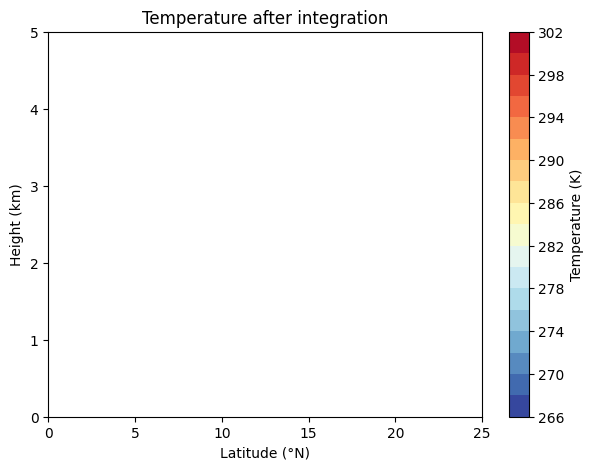

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Domain
# ==========================================================

y_min = 0.0           # degrees North
y_max = 25.0
ny = 101

z_min = 0.0           # metres
z_max = 5000.0
nz = 81

y = np.linspace(y_min, y_max, ny)
z = np.linspace(z_min, z_max, nz)

dy = (y_max - y_min) / (ny - 1)
dz = (z_max - z_min) / (nz - 1)

Y, Z = np.meshgrid(y, z)

# ==========================================================
# Time
# ==========================================================

dt = 300.0           # 5 minutes

nsteps = 1000

# ==========================================================
# Physical parameters
# ==========================================================

K = 50.0             # m² s⁻¹

# ==========================================================
# Initial temperature profile
# ==========================================================

T = 300.0 - 6.5 * Z / 1000.0

# ==========================================================
# Heating function
# ==========================================================

Q = (
    2.0e-5
    * np.exp(-((Y - 20.0) / 3.0) ** 2)
    * np.exp(-Z / 2500.0)
)

Q += (
    -1.5e-5
    * np.exp(-((Y - 5.0) / 3.0) ** 2)
    * np.exp(-Z / 2500.0)
)

# ==========================================================
# Time integration
# ==========================================================

for n in range(nsteps):

    laplacian = np.zeros_like(T)

    # y diffusion
    laplacian[:,1:-1] += (
        T[:,2:]
        -2*T[:,1:-1]
        +T[:,:-2]
    ) / dy**2

    # z diffusion
    laplacian[1:-1,:] += (
        T[2:,:]
        -2*T[1:-1,:]
        +T[:-2,:]
    ) / dz**2

    rhs = Q + K * laplacian

    T += dt * rhs

# ==========================================================
# Plot
# ==========================================================

plt.figure(figsize=(7,5))

plt.contourf(
    y,
    z/1000,
    T,
    20,
    cmap="RdYlBu_r"
)

plt.colorbar(label="Temperature (K)")

plt.xlabel("Latitude (°N)")
plt.ylabel("Height (km)")
plt.title("Temperature after integration")

plt.show()

In [2]:
# Advection with constant velocity vector in a double periodic domain

import numpy as np
import matplotlib.pyplot as plt
from nums.pynums.pdes.timemarching import *
from nums.pynums.pdes.checkpointing import *
from nums.pynums.pdes.postprocessing import *
from nums.pynums.iodata import *

# Define the temporal grid
tmin = 0.0  # Initial time
tmax = 2.0  # Final time
tcheck = 0.05  # Time interval to checkpoint data

# Define the spatial grid, uniformly spaced
xmin = -2.0
xmax = 2.0
nx = 79

ymin = -1.0
ymax = 1.0
ny = 39

# Define the problem
velocity = 1.0
angle = np.pi / 4.0
velocity_x = velocity * np.cos(angle)
velocity_y = velocity * np.sin(angle)
# timescheme = Euler(delta_t=0.2)
timescheme = RungeKutta3()
cnum = 0.20  # Choose if you fix diffusion number or time step


###########################################################
def reference(grid):
    xc = grid[0]  # for clarity
    yc = grid[1]
    return np.sin(0.5 * np.pi * xc) ** 2 * np.cos(0.5 * np.pi * yc) ** 2


def preprocessing():
    # Construct grid (periodic)
    x = np.linspace(xmin, xmax, nx + 1)[:-1]
    y = np.linspace(ymin, ymax, ny + 1)[:-1]
    grid = np.meshgrid(x, y)  # 2-tuple containing xc, yc

    # Construct initial condition
    u = reference(grid)

    return grid, u


((array([[-2.        , -1.94936709, -1.89873418, ...,  1.84810127,
           1.89873418,  1.94936709],
         [-2.        , -1.94936709, -1.89873418, ...,  1.84810127,
           1.89873418,  1.94936709],
         [-2.        , -1.94936709, -1.89873418, ...,  1.84810127,
           1.89873418,  1.94936709],
         ...,
         [-2.        , -1.94936709, -1.89873418, ...,  1.84810127,
           1.89873418,  1.94936709],
         [-2.        , -1.94936709, -1.89873418, ...,  1.84810127,
           1.89873418,  1.94936709],
         [-2.        , -1.94936709, -1.89873418, ...,  1.84810127,
           1.89873418,  1.94936709]]),
  array([[-1.        , -1.        , -1.        , ..., -1.        ,
          -1.        , -1.        ],
         [-0.94871795, -0.94871795, -0.94871795, ..., -0.94871795,
          -0.94871795, -0.94871795],
         [-0.8974359 , -0.8974359 , -0.8974359 , ..., -0.8974359 ,
          -0.8974359 , -0.8974359 ],
         ...,
         [ 0.84615385,  0.84615385

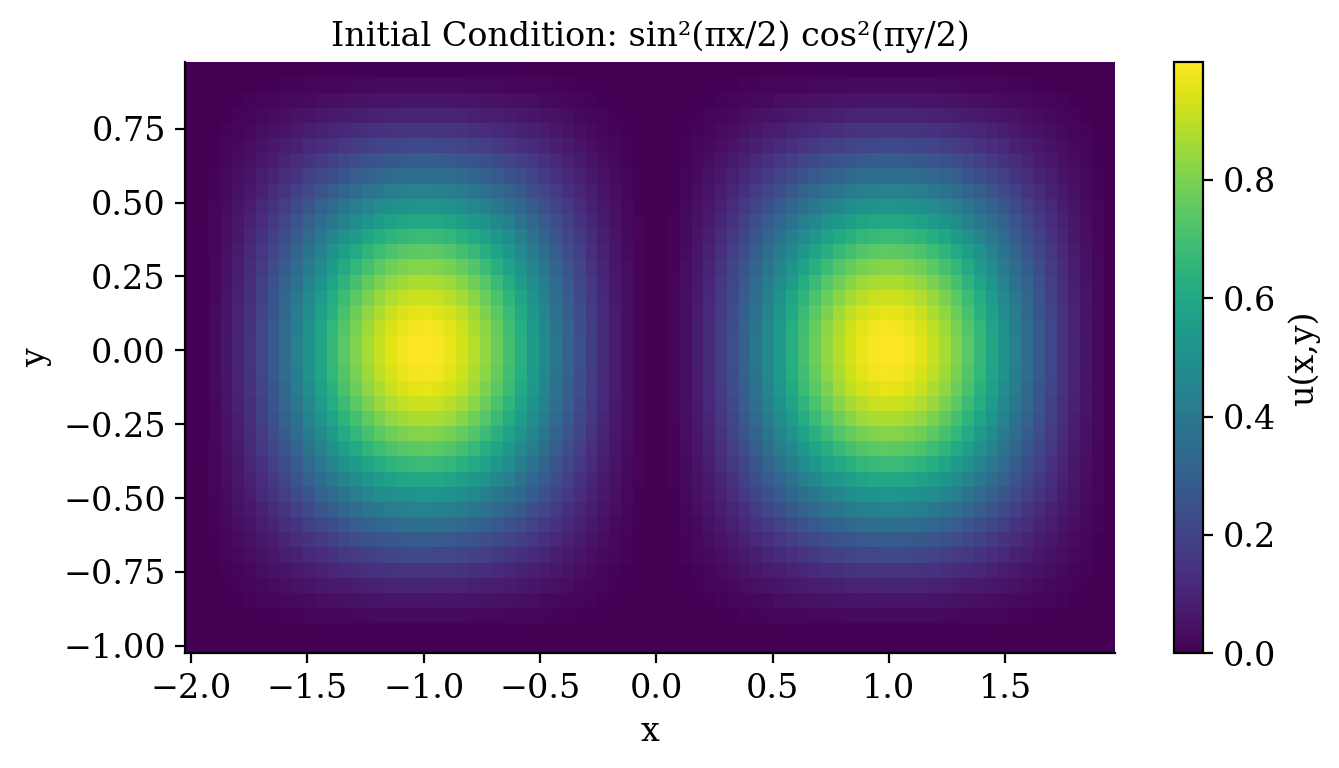

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

xmin, xmax, nx = -2.0, 2.0, 79
ymin, ymax, ny = -1.0, 1.0, 39

# Build periodic grid
x = np.linspace(xmin, xmax, nx + 1)[:-1]
y = np.linspace(ymin, ymax, ny + 1)[:-1]
xc, yc = np.meshgrid(x, y)

# Initial condition
u0 = np.sin(0.5 * np.pi * xc)**2 * np.cos(0.5 * np.pi * yc)**2

plt.figure(figsize=(7,4))
plt.pcolormesh(xc, yc, u0, shading='auto', cmap='viridis')
plt.colorbar(label='u(x,y)')
plt.title('Initial Condition: sin²(πx/2) cos²(πy/2)')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()


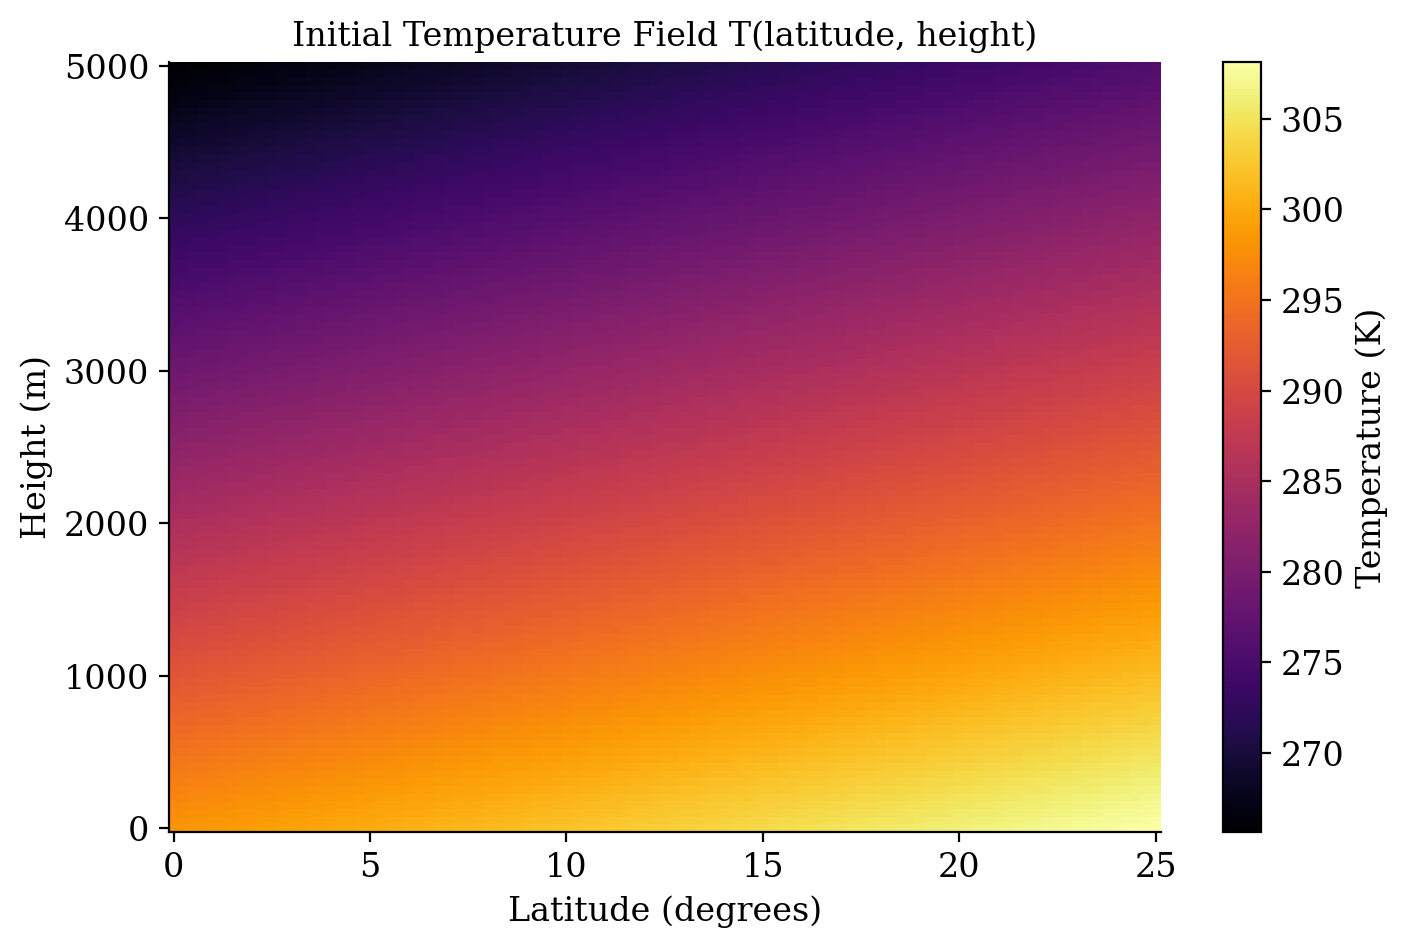

In [9]:
# Advection with constant velocity vector in a double periodic domain

import numpy as np
import matplotlib.pyplot as plt
from nums.pynums.pdes.timemarching import *
from nums.pynums.pdes.checkpointing import *
from nums.pynums.pdes.postprocessing import *
from nums.pynums.iodata import *

# ---------------------------------------------------------
# Temporal grid
tmin = 0.0
tmax = 2.0
tcheck = 0.05

# ---------------------------------------------------------
# Spatial grid (latitude × height)
xmin = 0.0        # latitude min (deg)
xmax = 25.0       # latitude max (deg)
nx = 101

zmin = 0.0        # height min (m)
zmax = 5000.0     # height max (m)
nz = 101

# ---------------------------------------------------------
# Advection velocity
velocity = 1.0
angle = np.pi / 4.0
velocity_x = velocity * np.cos(angle)
velocity_y = velocity * np.sin(angle)

timescheme = RungeKutta3()
cnum = 0.20

# ---------------------------------------------------------
def preprocessing():
    # Latitude coordinate (0–25 degrees)
    x = np.linspace(xmin, xmax, nx)

    # Height coordinate (0–5000 m)
    z = np.linspace(zmin, zmax, nz)

    # Build grid
    xc, zc = np.meshgrid(x, z)

    # Surface temperature profile T(lat)
    T_surface = 0.4 * xc + 298.15

    # Apply lapse rate
    lapse_rate = 0.0065  # K/m
    T = T_surface - lapse_rate * zc

    return (xc, zc), T

# ---------------------------------------------------------
# Build the grid and temperature field
(grid, T) = preprocessing()
xc, zc = grid

# ---------------------------------------------------------
# Plot the initial temperature field
plt.figure(figsize=(8,5))
plt.pcolormesh(xc, zc, T, shading='auto', cmap='inferno')
plt.colorbar(label='Temperature (K)')
plt.xlabel('Latitude (degrees)')
plt.ylabel('Height (m)')
plt.title('Initial Temperature Field T(latitude, height)')
plt.show()


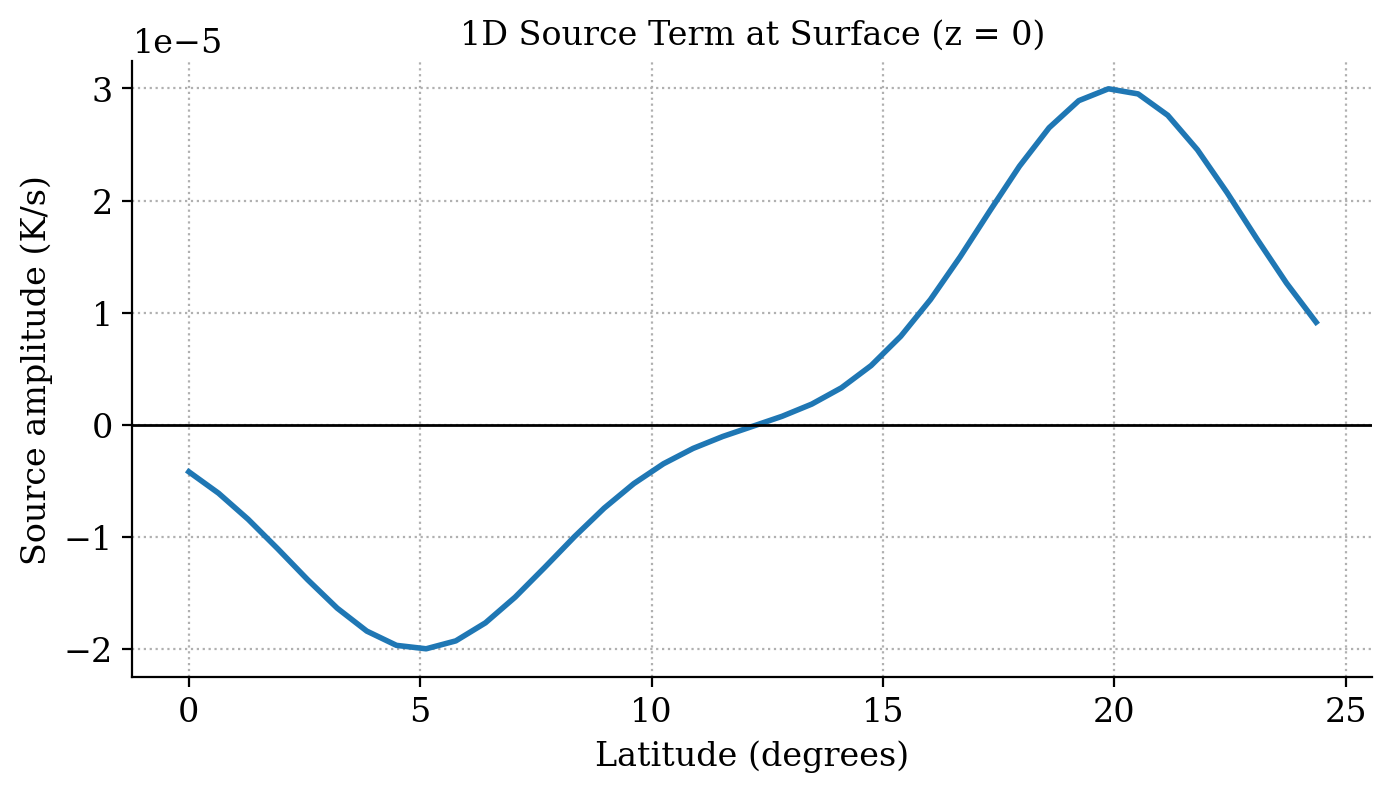

In [11]:
def source(grid, t):
    z = grid[0]
    y = grid[1]

    # Sahara heating
    sahara = (
        3e-5
        * np.exp(-((y-20)/4)**2)
        * np.exp(-z/2500)
    )

    # Gulf of Guinea cooling
    gulf = (
        -2e-5
        * np.exp(-((y-5)/4)**2)
        * np.exp(-z/2500)
    )

    return sahara + gulf


# Build latitude and height arrays
y = np.linspace(y_min, y_max, ny+1)[:-1]
z = np.linspace(z_min, z_max, nz+1)[:-1]

Y, Z = np.meshgrid(y, z)

# Evaluate source at t = 0
S = source((Z, Y), t=0.0)

# Extract the surface slice (z = 0)
S_surface = S[0, :]

plt.figure(figsize=(8,4))
plt.plot(y, S_surface, linewidth=2)
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Latitude (degrees)")
plt.ylabel("Source amplitude (K/s)")
plt.title("1D Source Term at Surface (z = 0)")
plt.grid(True)
plt.show()

